In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
import tidy3d.web as web
import math
from pathlib import Path
import os
import gdstk
from PIL.ImageChops import offset

# --- 1. Material Definitions ---
# Using fixed indices for 1550nm for simplicity

wavelength =  1.55                              # Central wavelength
wv_points = 50                   # number of wavelength wv_points
width= 0.310               # Anchos optimizados para tener single mode regimen
n_si = 3.475
n_sio2 = 1.458
output_offset = 3.5


sweep_wavelength = np.linspace(1.5,1.6,wv_points)  # Sweep on wavelengths
sweep_freq = td.C_0 / sweep_wavelength          # Sweep on Frequencies


bandwidth = sweep_wavelength[-1]-sweep_wavelength[0]

mat_si = td.material_library["cSi"]["Li1993_293K"] # Material trace permitivity model for crystaline Silicon
mat_sio2 = td.material_library["SiO2"]["Horiba"]   # Material trace permitivity model for crystaline Silica

web.configure("U7IS5Q1AW3qYVxPAAQDE7vgxaTz6Kt6aI9AioPZUajVRQQ2o")

Configuration saved successfully.


In [2]:
version_name = "Ybranch_sharp_v6"

project_dir = Path.cwd()  # directory where notebook is located
data_dir = project_dir / "data_hom2_point4"
data_dir.mkdir(parents=True, exist_ok=True)


def build_Ybranch_simulation(
    gds=["filename"],
    thickness=np.array([0.22, 0.30]),
    wavelength=np.array([1.55]),
    version_name="sim_name",
):

    base_path = f"data_hom2_point4/{version_name}"
    os.makedirs(base_path, exist_ok=True)

    freq = td.C_0 / wavelength
    freq0 = td.C_0 / wavelength.mean()
    fwidth = (td.C_0 / wavelength.min()) - (td.C_0 / wavelength.max())

    sim_data_arr = [[],[]]
    sim_arr = [[],[]]

    estimate = 0

    # =========================================
    # Loop over thickness
    # =========================================

    for thick_idx, thick in enumerate(thickness):

        thick_folder = f"{base_path}/t{int(thick*1000)}"
        os.makedirs(thick_folder, exist_ok=True)

        for gds_idx, gds_file in enumerate(gds):

            filename = f"{thick_folder}/{Path(gds_file).stem}.hdf5"

            # =========================================
            # --- Import GDS Automatically ------------
            # =========================================

            lib = gdstk.read_gds(gds_file)


            if gds_idx == 0 :
                cell_name = "horizontal_Y_S_bend"   # change accordingly
                top_cell = lib[cell_name]
            else:
                cell_name = "adiabatic_y_branch"   # change accordingly
                top_cell = lib[cell_name]


            # Flatten hierarchy
            top_cell.flatten()


            # GDS scale conversion (important!)
            gds_scale = lib.unit / 1e-6

            # Extrude silicon layer (Layer 1 / datatype 0 assumed)
            polys = td.PolySlab.from_gds(
                top_cell,
                gds_layer=1,
                gds_dtype=0,
                axis=2,
                slab_bounds=(-thick/2, thick/2),
                gds_scale=gds_scale,
                reference_plane="middle",
            )

            silicon_structure = td.Structure(
                geometry=td.GeometryGroup(geometries=polys),
                medium=mat_si,
            )

            # =========================================
            # --- Source & Monitors -------------------
            # =========================================

            # Input assumed at left side of layout
            source = td.ModeSource(
                name="Input_Source",
                center=[-7, 0, 0],
                size=[0, 2, 2],
                source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
                direction="+",
                mode_index=0,
                mode_spec=td.ModeSpec(num_modes=5, target_neff=n_si),
            )


            # Reflection monitor
            monitor_reflc= td.FieldMonitor(
                name="mon_Reflect",
                center=[-8, 0,0],
                size=[0, 1, 1],
                freqs=freq,
            )

            # Input monitors
            monitor_in= td.FieldMonitor(
                name="mon_Input",
                center=[-6, 0,0],
                size=[0, 1, 1],
                freqs=freq,
            )

            if gds_idx == 0 :

                # Output1 monitors
                monitor_out1= td.FieldMonitor(
                    name="mon_Output1",
                    center=[42, output_offset,0],
                    size=[0, 1, 1],
                    freqs=freq,
                )

                # Output monitors
                monitor_out2= td.FieldMonitor(
                    name="mon_Output2",
                    center=[42, -output_offset,0],
                    size=[0, 1, 1],
                    freqs=freq,
                )

            else:
                # Output1 monitors
                monitor_out1= td.FieldMonitor(
                    name="mon_Output1",
                    center=[42, 0.8,0],
                    size=[0, 1, 1],
                    freqs=freq,
                )

                # Output monitors
                monitor_out2= td.FieldMonitor(
                    name="mon_Output2",
                    center=[42, -0.8,0],
                    size=[0, 1, 1],
                    freqs=freq,
                )

            monitor_longitudinal = td.FieldMonitor(
                name="Longitudinal",
                size=[td.inf, 10, 0],
                freqs=freq,
            )

            # =========================================
            # --- Simulation Definition --------------
            # =========================================

            sim = td.Simulation(
                center = (17,0,0),
                size=(54, 12, 8),
                structures=[silicon_structure],
                sources=[source],
                monitors=[monitor_out1,monitor_out2, monitor_in,monitor_reflc, monitor_longitudinal],
                medium=mat_sio2,
                symmetry=(0, 0, 1),
                run_time=1e-12,
                grid_spec=td.GridSpec.auto(
                    wavelength=wavelength.min(),
                    min_steps_per_wvl=12,
                ),
            )




            sim_arr[thick_idx].append(sim)

            # =========================================
            # --- Load or Run -------------------------
            # =========================================

            if os.path.exists(filename):
                print(f"Loading {filename}")
                filename_path = Path(filename)
                sim_data_arr[thick_idx].append(
                    td.SimulationData.from_file(filename_path)
                )

            else:
                task_name = f"{version_name}_t{int(thick*1000)}"
                filename_path = Path(filename)
                job = web.Job(simulation=sim, task_name=task_name)

                print(f"Running simulation: {task_name}")

                sim_data = job.run()
                sim_data.to_file(filename_path)

                sim_data_arr[thick_idx].append(sim_data)

                estimate += job.estimate_cost()
                print(f"Estimated Maximum Cost So Far: {estimate}")

    return sim_data_arr, sim_arr


sim_data, sim = build_Ybranch_simulation(gds=["horizontal_Y_S_bend.gds","horizontal_Y_S_bend_adiabatic.gds"],wavelength=sweep_wavelength, version_name= version_name)



Running simulation: Ybranch_sharp_v6_t220


20:32:06 Hora est. Pacífico, Sudamérica Created task 'Ybranch_sharp_v6_t220'    
                                        with resource_id                        
                                        'fdve-27929d57-a9f5-48e9-a8d7-34bef8e61b
                                        a8' and task_type 'FDTD'.

                                        View task using web UI at               
                                        ]8;id=239518;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\'https://tidy3d.simulation.cloud/workben]8;;\
                                        ]8;id=239518;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\ch?]8;;\]8;id=10901;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\taskId]8;;\]8;id=239518;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\=]8;;\]8;id=536996;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\fdve]8;;\]8;id=239518;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\-27929d57-a9f5-48e9-a8d7-3]8;;\
                                        ]8;id=239518;https://tidy3d.simulation.cloud/workbench?taskId=fdve-27929d57-a9f5-48e9-a8d7-34bef8e61ba8\4bef8e61ba8']8;;\.

                                        Task folder: ]8;id=119150;https://tidy3d.simulation.cloud/folders/folder-6a6c7c15-3e31-4e28-8c62-ab0ed77742eb\'default']8;;\.

D:\GitHub\GDS_py_TDY_venv\.venv\Lib\site-packages\rich\live.py:231: UserWarning:
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

20:39:01 Hora est. Pacífico, Sudamérica Loading simulation from                 
                                        simulation_data.hdf5

20:39:03 Hora est. Pacífico, Sudamérica WARNING: Simulation final field decay   
                                        value of 4.18e-05 is greater than the   
                                        simulation shutoff threshold of 1e-05.  
                                        Consider running the simulation again   
                                        with a larger 'run_time' duration for   
                                        more accurate results.                  

                                        WARNING: Warning messages were found in 
                                        the solver log. For more information,   
                                        check 'SimulationData.log' or use       
                                        'web.download_log(task_id)'.            

20:39:07 Hora est. Pacífico, Sudamérica Estimated FlexCredit cost: 0.173.       
                                        Minimum cost depends on task execution  
                                        details. Use 'web.real_cost(task_id)' to
                                        get the billed FlexCredit cost after a  
                                        simulation run.

Estimated Maximum Cost So Far: 0.842305524550654


In [5]:
IN, OUT1,OUT2, Longitudinal, Reflect = [[],[]],[[],[]],[[],[]],[[],[]],[[],[]]

for thick_idx in range(2):
    for gds_idx in range(2):
        IN[thick_idx].append(sim_data[thick_idx][gds_idx]["mon_Input"])
        OUT1[thick_idx].append(sim_data[thick_idx][gds_idx]["mon_Output1"])
        OUT2[thick_idx].append(sim_data[thick_idx][gds_idx]["mon_Output2"])
        Longitudinal[thick_idx].append(sim_data[thick_idx][gds_idx]["Longitudinal"])
        Reflect[thick_idx].append(sim_data[thick_idx][gds_idx]["mon_Reflect"])


# A continuacion vamos  a hacer los plots necesarios que pide la tarea,

"""
1. Mostrar las dos geometrias por plataforma , mostrando la vista transversal  LISTO
2.  Calculo del insertion loss para las las dos geometrias en sus distintas plataformas, usar monitor in y monitor out e integrar hasta la mitad, mostrar una imagen del monitor de salida para ver que todo este en orden
3.  usar el anterior y ver si hay imbalanzas (diferencias tanto calculando el lado izquierdo como el lado derecho)
4. usar el monitor de refleccion para medir la cantidad de luz de reflexion con respecto a la potencia de entrada, sacar porcentajes.
5. hacer un barrido en wavelength
"""


'\n1. Mostrar las dos geometrias por plataforma , mostrando la vista transversal  LISTO\n2.  Calculo del insertion loss para las las dos geometrias en sus distintas plataformas, usar monitor in y monitor out e integrar hasta la mitad, mostrar una imagen del monitor de salida para ver que todo este en orden\n3.  usar el anterior y ver si hay imbalanzas (diferencias tanto calculando el lado izquierdo como el lado derecho)\n4. usar el monitor de refleccion para medir la cantidad de luz de reflexion con respecto a la potencia de entrada, sacar porcentajes.\n5. hacer un barrido en wavelength\n'

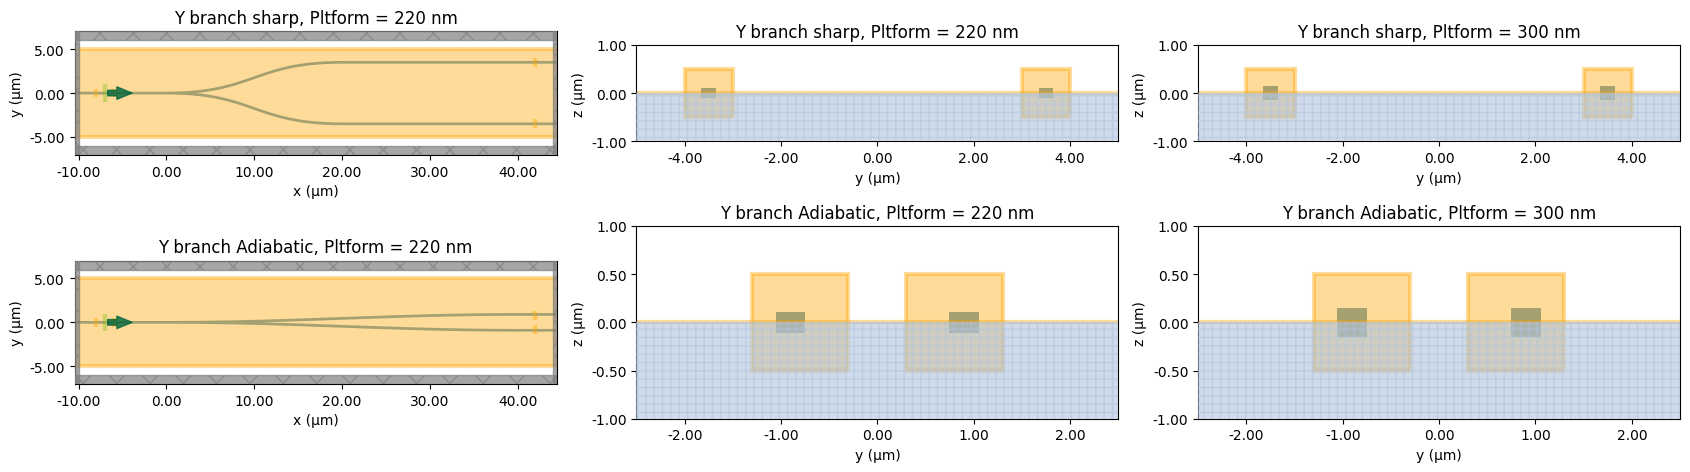

In [6]:
#------- Primer reto ---------

fig0, axes0 = plt.subplots(2, 3, figsize=(17, 5))
sim[0][0].plot(z = 0, lw=1, ax=axes0[0][0]) # Vista superior
axes0[0][0].set_title(f"Y branch sharp, Pltform = {[220,300][0]} nm")


sim[0][0].plot(x=42, lw=1, ax=axes0[0][1])   # Vista transversal Single mode waveguides a 220 nm
axes0[0][1].set_xlim([-5, 5])
axes0[0][1].set_ylim([-1, 1])
axes0[0][1].set_title(f"Y branch sharp, Pltform = {[220,300][0]} nm")


sim[1][0].plot(x=42, lw=1, ax=axes0[0][2])   # Vista transversal Single mode waveguides a 300 nm
axes0[0][2].set_xlim([-5, 5])
axes0[0][2].set_ylim([-1, 1])
axes0[0][2].set_title(f"Y branch sharp, Pltform = {[220,300][1]} nm")





sim[0][1].plot(z=0, lw=1, ax=axes0[1][0])   # Vista transversal Single mode waveguides a 220 nm
axes0[1][0].set_title(f"Y branch Adiabatic, Pltform = {[220,300][0]} nm")


sim[0][1].plot(x=42, lw=1, ax=axes0[1][1])   # Vista transversal Single mode waveguides a 300 nm
axes0[1][1].set_xlim([-2.5, 2.5])
axes0[1][1].set_ylim([-1, 1])
axes0[1][1].set_title(f"Y branch Adiabatic, Pltform = {[220,300][0]} nm")


sim[1][1].plot(x=42, lw=1, ax=axes0[1][2])   # Vista transversal Single mode waveguides a 300 nm
axes0[1][2].set_xlim([-2.5, 2.5])
axes0[1][2].set_ylim([-1, 1])
axes0[1][2].set_title(f"Y branch Adiabatic, Pltform = {[220,300][1]} nm")


plt.tight_layout()
plt.show()

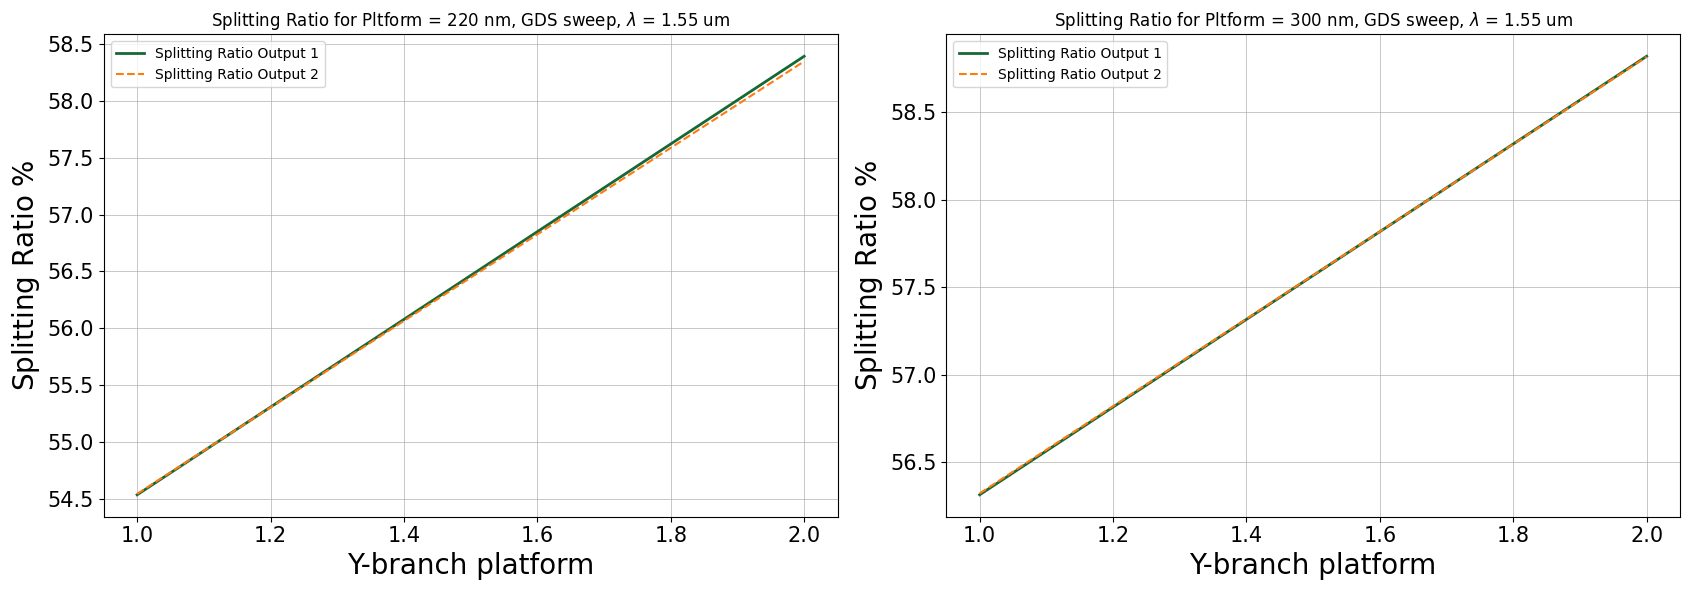

In [46]:
## Mediremos el insertion loss usando el monitor de salida y relativo al monitor de entrada
fig4, axes4 = plt.subplots(1, 2, figsize=(17, 6))

gds_points = 2

gap = 10

Splitting_ratio_OUT1 = np.zeros(gds_points)
Splitting_ratio_OUT2 = np.zeros(gds_points)

wv_fixed = 24  # a 1550 nm
Losses_220 = np.zeros(gds_points)
Losses_300 = np.zeros(gds_points)

for thick_idx in range(2):
    for gds_idx in range(0,gds_points):
        ## Calculo de potencia para el monitor de entrada

        Ey_INR = IN[thick_idx][gds_idx].Ey.isel(f=wv_fixed).squeeze()  # La componente real Ey a 1550 nm
        Ez_INR = IN[thick_idx][gds_idx].Ez.isel(f=wv_fixed).squeeze()  # La componente real Ez a 1550 nm

        Hy_INR = IN[thick_idx][gds_idx].Hy.isel(f=wv_fixed).squeeze()  # La componente real Hy a 1550 nm
        Hz_INR = IN[thick_idx][gds_idx].Hz.isel(f=wv_fixed).squeeze()  # La componente real Hz a 1550 nm

        Sx_INR = 0.5 * np.real(Ey_INR * np.conj(Hz_INR) - Ez_INR * np.conj(Hy_INR))

        arr_Sx_INR = Sx_INR.values

        x_coords_IN = Ey_INR.coords['y'].values
        y_coords_IN = Ey_INR.coords['z'].values

        dx = np.diff(x_coords_IN).mean()
        dy = np.diff(y_coords_IN).mean()

        P_IN = np.sum(arr_Sx_INR) * dx * dy

        ## Vamos a hacer lo mismo para OUT

        Ey_OUT1R = OUT1[thick_idx][gds_idx].Ey.isel(f=wv_fixed).squeeze()  # La componente real Ey a 1550 nm
        Ez_OUT1R = OUT1[thick_idx][gds_idx].Ez.isel(f=wv_fixed).squeeze()  # La componente real Ez a 1550 nm

        Hy_OUT1R = OUT1[thick_idx][gds_idx].Hy.isel(f=wv_fixed).squeeze()  # La componente real Hy a 1550 nm
        Hz_OUT1R = OUT1[thick_idx][gds_idx].Hz.isel(f=wv_fixed).squeeze()  # La componente real Hz a 1550 nm

        Sx_OUT1R = 0.5 * np.real(Ey_OUT1R * np.conj(Hz_OUT1R) - Ez_OUT1R * np.conj(Hy_OUT1R))

        x_coords_OUT1 = Sx_OUT1R.coords['y'].values
        y_coords_OUT1 = Sx_OUT1R.coords['z'].values

        arr_Sx_OUT1R = Sx_OUT1R.values

        dx = np.diff(x_coords_OUT1).mean()
        dy = np.diff(y_coords_OUT1).mean()

        arr_Sx_OUT1R = Sx_OUT1R.values

        P_OUT1 = np.sum(arr_Sx_OUT1R[0:middle_pos-gap]) * dx * dy


        Ey_OUT2R = OUT2[thick_idx][gds_idx].Ey.isel(f=wv_fixed).squeeze()  # La componente real Ey a 1550 nm
        Ez_OUT2R = OUT2[thick_idx][gds_idx].Ez.isel(f=wv_fixed).squeeze()  # La componente real Ez a 1550 nm

        Hy_OUT2R = OUT2[thick_idx][gds_idx].Hy.isel(f=wv_fixed).squeeze()  # La componente real Hy a 1550 nm
        Hz_OUT2R = OUT2[thick_idx][gds_idx].Hz.isel(f=wv_fixed).squeeze()  # La componente real Hz a 1550 nm

        Sx_OUT2R = 0.5 * np.real(Ey_OUT2R * np.conj(Hz_OUT2R) - Ez_OUT2R * np.conj(Hy_OUT2R))

        x_coords_OUT2 = Sx_OUT2R.coords['y'].values
        y_coords_OUT2 = Sx_OUT2R.coords['z'].values

        arr_Sx_OUT1R = Sx_OUT1R.values

        dx = np.diff(x_coords_OUT1).mean()
        dy = np.diff(y_coords_OUT1).mean()

        arr_Sx_OUT1R = Sx_OUT1R.values

        P_OUT1 = np.sum(arr_Sx_OUT1R[0:middle_pos-gap]) * dx * dy



        P_OUT2 = np.sum(arr_Sx_OUT1R[middle_pos+gap:-1]) * dx * dy


        # Calculamos el Splitting ratio

        Splitting_ratio_OUT1[gds_idx] = P_OUT1 *100/ P_IN
        Splitting_ratio_OUT2[gds_idx] = P_OUT2 *100 / P_IN

        # if thick_idx == 0:
        #     Losses_220[gds_idx] = 10*math.log10((P_IN-(P_OUT1+P_OUT2))/P_IN)
        # else:
        #     Losses_300[gds_idx] = 10*math.log10((P_IN-(P_OUT1+P_OUT2))/P_IN)


    axes4[thick_idx].plot(np.array([1,2]), Splitting_ratio_OUT1, label="Splitting Ratio Output 1", lw=2)
    axes4[thick_idx].plot(np.array([1,2]), Splitting_ratio_OUT2, label="Splitting Ratio Output 2", linestyle='--')
    axes4[thick_idx].set_title(
        fr"Splitting Ratio for Pltform = {[220, 300][thick_idx]} nm, GDS sweep, $\lambda$ = {sweep_wavelength[wv_fixed]:.2f} um")
    axes4[thick_idx].set_xlabel(r"Y-branch platform", fontsize=20)
    axes4[thick_idx].set_ylabel(r"Splitting Ratio $\%$", fontsize=20)
    axes4[thick_idx].legend(loc='best')
    axes4[thick_idx].grid(True, lw=0.5)
    axes4[thick_idx].tick_params(axis='both', labelsize=15)

plt.tight_layout()
plt.show()


# fig_loss1, ax_loss1 = plt.subplots(1,2,figsize=(14,8))
#
#
# ax_loss1[0].plot(sweep_MMI_L, Losses_220, label="Insertion Loss", linestyle='--')
# ax_loss1[0].set_title(
#     f"Insertion Loss, Pltf = {[220, 300][0]} nm, Length sweep, width = {sweep_MMI_W[width_fixed]:.2f} um , $\lambda$ = {sweep_wavelength[wv_fixed]:.2f} um", fontsize = 13)
# ax_loss1[0].set_xlabel(r"MMI Length [um]", fontsize = 20)
# ax_loss1[0].set_ylabel(r"Loss (dBs)", fontsize = 20)
# ax_loss1[0].grid(True, lw=0.5)
# ax_loss1[0].tick_params(axis='both', labelsize=15)
#
# ax_loss1[1].plot(sweep_MMI_L, Losses_300, label="Insertion Loss", linestyle='--')
# ax_loss1[1].set_title(
#     f"Insertion Loss, Pltf = {[220, 300][1]} nm, Length sweep, width = {sweep_MMI_W[width_fixed]:.2f} um, , $\lambda$ = {sweep_wavelength[wv_fixed]:.2f} um")
# ax_loss1[1].set_xlabel(r"MMI Length [um]", fontsize = 20)
# ax_loss1[1].set_ylabel(r"Loss (dBs)", fontsize = 20)
# ax_loss1[1].grid(True, lw=0.5)
# ax_loss1[1].tick_params(axis='both', labelsize=15)
#
# plt.tight_layout()
# plt.show()